<a href="https://colab.research.google.com/github/FrankHolzkamp/FundamentalsActiveInference/blob/main/Plot%20lernen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [2]:
mu = 5  # Mean
sigma = 3  # Standard deviation

In [9]:
# Generate x values
x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 1000)

# Calculate the probability density function (PDF)
pdf = norm.pdf(x, mu, sigma)

In [10]:
print(f"Type of pdf: {type(pdf)}")
print(f"Dimensions of pdf: {pdf.shape}")

Type of pdf: <class 'numpy.ndarray'>
Dimensions of pdf: (1000,)


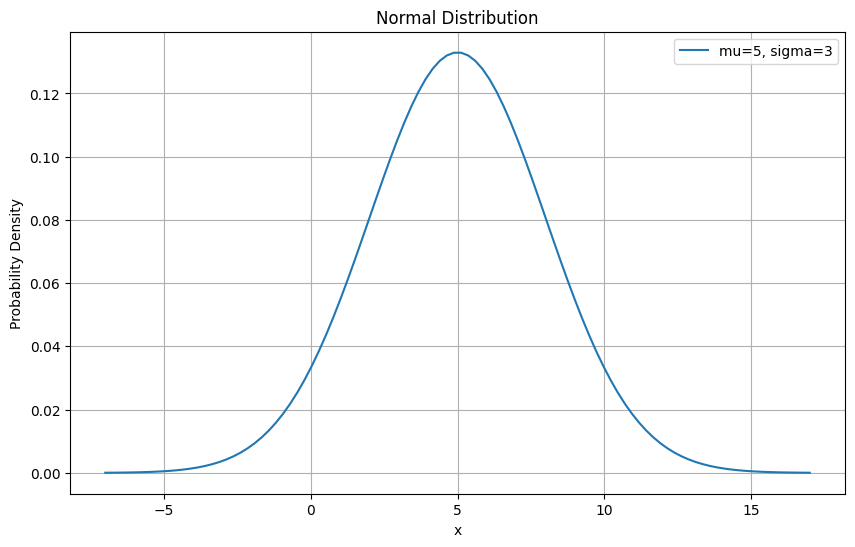

In [8]:
# Plot the normal distribution
plt.figure(figsize=(10, 6))
plt.plot(x, pdf, label=f'mu={mu}, sigma={sigma}')
plt.title('Normal Distribution')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.grid(True)
plt.legend()
plt.show()

In [13]:
from scipy.stats import multivariate_normal

In [20]:
# Parameters for a 2D normal distribution
mu_x = 10
sigma_x = 1.5
mu_y = 5 # Using the same mean and std dev as the 1D case for consistency
sigma_y = 1.5
rho = 0.5 # Correlation coefficient (between -1 and 1)

In [21]:
# Create a grid of x and y values
x_2d = np.linspace(mu_x - 4 * sigma_x, mu_x + 4 * sigma_x, 100)
y_2d = np.linspace(mu_y - 4 * sigma_y, mu_y + 4 * sigma_y, 100)
X, Y = np.meshgrid(x_2d, y_2d)

# Combine into a single array for multivariate_normal
pos = np.empty(X.shape + (2,))
pos[:, :, 0] = X
pos[:, :, 1] = Y

# Define the mean vector and covariance matrix
mean_2d = [mu_x, mu_y]
cov_matrix = [
    [sigma_x**2, rho * sigma_x * sigma_y],
    [rho * sigma_x * sigma_y, sigma_y**2]
]

# Calculate the 2D PDF
z_2d = multivariate_normal(mean_2d, cov_matrix).pdf(pos)

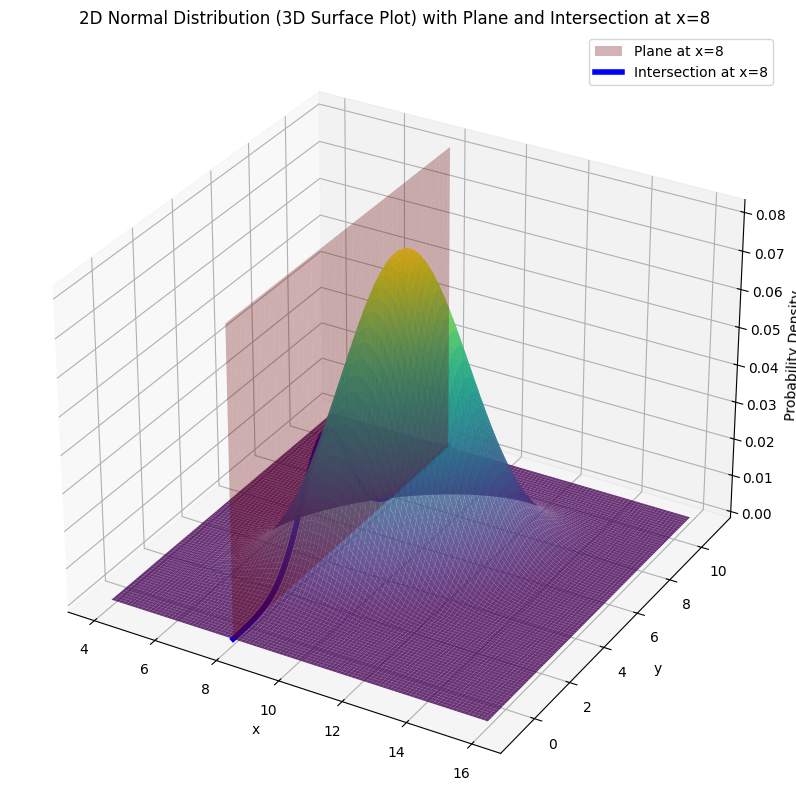

In [24]:
# Plot the 2D normal distribution as a 3D surface plot
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, z_2d, cmap='viridis', rstride=1, cstride=1, alpha=0.8)

# Add a plane at x = 8
y_plane_values = np.linspace(y_2d.min(), y_2d.max(), 100)
z_plane_values = np.linspace(0, z_2d.max(), 100) # Span from 0 to max density
Y_plane_mesh, Z_plane_mesh = np.meshgrid(y_plane_values, z_plane_values)
X_plane_mesh = np.full_like(Y_plane_mesh, 8)
ax.plot_surface(X_plane_mesh, Y_plane_mesh, Z_plane_mesh, color='red', alpha=0.3, label='Plane at x=8') # Make plane slightly more transparent

# Highlight the intersection line
plane_x_value = 8
idx_for_intersection = np.argmin(np.abs(x_2d - plane_x_value))

intersection_y = y_2d # Y values for the intersection will be the entire y_2d range
intersection_z = z_2d[:, idx_for_intersection]
intersection_x = np.full_like(intersection_y, plane_x_value) # All x values for the intersection are 8

ax.plot(intersection_x, intersection_y, intersection_z, color='blue', linewidth=4, label=f'Intersection at x={plane_x_value}')

ax.set_title('2D Normal Distribution (3D Surface Plot) with Plane and Intersection at x=8')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('Probability Density')
ax.legend()
plt.show()

### Normalisierung der Kurve für P(Y|X=8)

Integral of the unnormalized curve: 0.1093


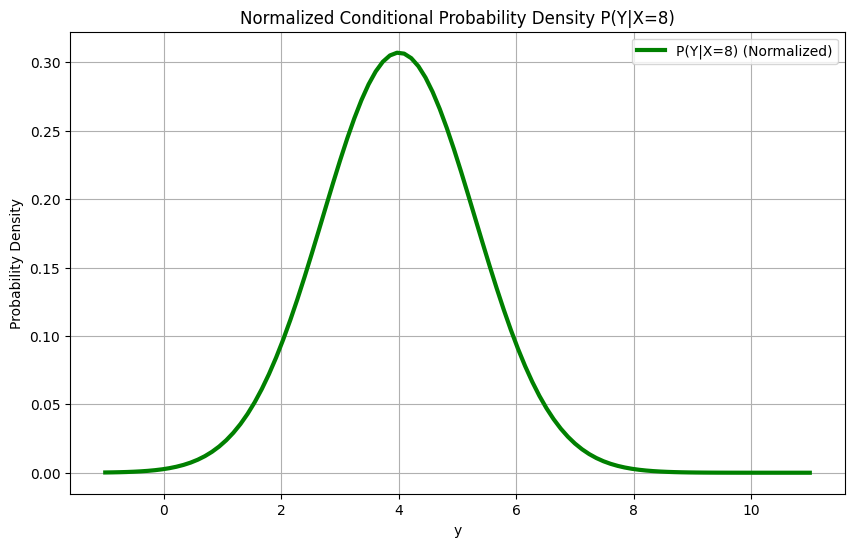

In [29]:
from scipy.integrate import trapezoid
import matplotlib.pyplot as plt

# Calculate the integral of the unnormalized conditional PDF
# The intersection_z represents P(Y|X=8) unnormalized, and intersection_y represents the y-values.
integral_value = trapezoid(intersection_z, intersection_y)

# Normalize the conditional PDF
normalized_conditional_pdf = intersection_z / integral_value

print(f"Integral of the unnormalized curve: {integral_value:.4f}")

# Plot the normalized conditional PDF
plt.figure(figsize=(10, 6))
plt.plot(intersection_y, normalized_conditional_pdf, color='green', linewidth=3, label=f'P(Y|X={plane_x_value}) (Normalized)')
plt.title(f'Normalized Conditional Probability Density P(Y|X={plane_x_value})')
plt.xlabel('y')
plt.ylabel('Probability Density')
plt.grid(True)
plt.legend()
plt.show()

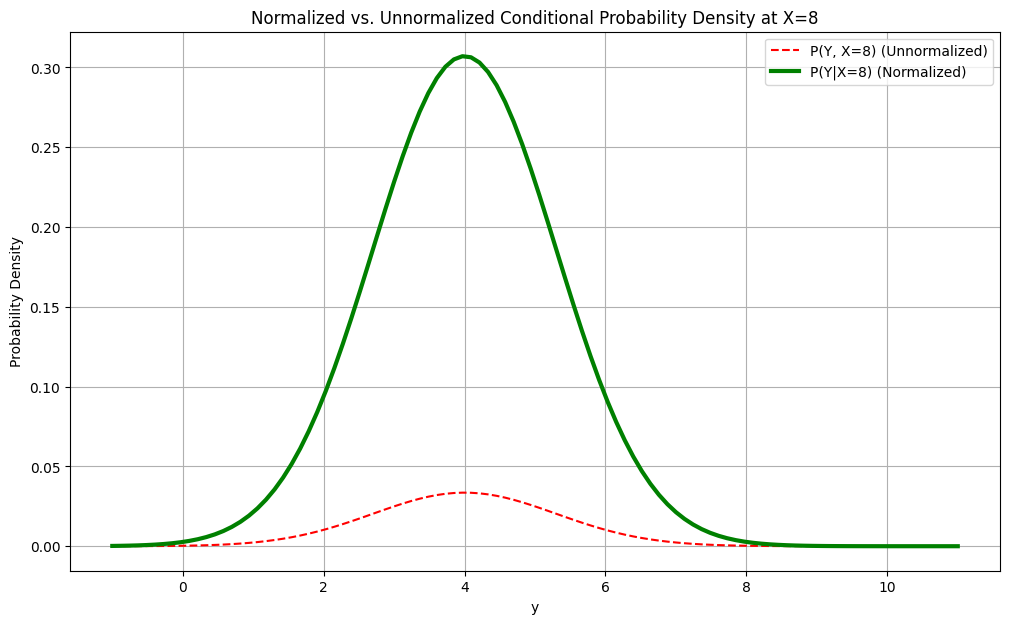

In [30]:
# Plot both the normalized and unnormalized conditional PDFs
plt.figure(figsize=(12, 7))

# Unnormalized PDF
plt.plot(intersection_y, intersection_z, color='red', linestyle='--', label=f'P(Y, X={plane_x_value}) (Unnormalized)')

# Normalized conditional PDF
plt.plot(intersection_y, normalized_conditional_pdf, color='green', linewidth=3, label=f'P(Y|X={plane_x_value}) (Normalized)')

plt.title(f'Normalized vs. Unnormalized Conditional Probability Density at X={plane_x_value}')
plt.xlabel('y')
plt.ylabel('Probability Density')
plt.grid(True)
plt.legend()
plt.show()